## **Введение**

### Генерация реалистичных изображений с помощью гибридной модели VAE-StyleGAN2, управляемой через CLIP
**Автор:** Сердцев Дмитрий, Группа №48

### Краткая аннотация
Данный проект представляет собой практическое исследование и реализацию **гибридной генеративной архитектуры**, которая объединяет ключевые преимущества трёх передовых подходов в области ИИ: вариационного автокодировщика (**VAE**), генеративно-состязательной сети (**GAN**) с элементами StyleGAN2-ADA и модели **CLIP**.

Главная цель работы — создать модель, которая не просто генерирует высококачественные и детализированные изображения, но и позволяет точно контролировать их содержание с помощью текстовых описаний. Это решает одну из основных проблем традиционных генеративных моделей — отсутствие интуитивного семантического управления.

### Ключевые особенности
* **Прогрессивное обучение:** Для обеспечения стабильности и достижения высокой детализации модель обучается поэтапно. Она начинает генерацию на низком разрешении (4x4) и постепенно увеличивает его до 128x128.
* **Гибридная архитектура:** Мы используем VAE для создания **гладкого и семантически богатого латентного пространства**. Это пространство, в свою очередь, подаётся в **StyleGAN2-подобный генератор**, который, благодаря модулированным свёрткам и шумовой инъекции, генерирует высококачественные изображения. Такой подход совмещает управляемость VAE с реализмом StyleGAN2.
* **CLIP-управляемая генерация:** Модель CLIP используется для вычисления **CLIP-потери**, которая заставляет сгенерированные изображения строго соответствовать текстовым запросам. Это позволяет модели понимать и воплощать в изображениях абстрактные концепции, например "улыбающийся молодой человек с светлыми волосами".

### **2. Установка и импорт библиотек**
Чтобы код работал, вам нужно установить и импортировать все необходимые библиотеки.


In [ ]:
# Установка основных библиотек
!pip install torch torchvision torchaudio
!pip install transformers==4.18.0
!pip install transformers

!pip install Pillow
!pip install matplotlib
!pip install scikit-learn
!pip install tqdm
!pip install pandas
!pip install seaborn

# Установка PyTorch Metrics для FID
!pip install torchmetrics

# Установка TensorBoard
!pip install tensorboard
!pip install torch-fidelity
!pip install torchmetrics[image]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.7/220.7 kB 15.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 38.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 41.2 MB/s eta 0:00:00




  * **`torch`**: Основная библиотека для создания нейросетей.
  * **`torchvision`**: Для работы с данными изображений и предобученными моделями.
  * **`transformers`**: Для загрузки модели CLIP, которая нужна для работы с текстом.
  * **`pandas`**, **`numpy`**: Для обработки и анализа данных, особенно для работы с метаданными CelebA.
  * **`matplotlib`**: Для визуализации сгенерированных изображений.
  * **`tqdm`**: Для отображения прогресса обучения.
  * **`scikit-learn`**: Для разделения данных на обучающую и валидационную выборки.


### Импорт бибилиотек


In [ ]:
# =========================================
# StyleCLIP-VAE + ProgressiveGAN (CelebA)
# Единый рефактор: обучение, метрики, виджеты
# =========================================

# ---------- 0. Импорт ----------
from google.colab import drive
import ipywidgets as widgets
from IPython.display import display, clear_output

import os, random, math, json, time, gc
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision.transforms import ToTensor, Normalize, Resize

from transformers import CLIPModel, CLIPProcessor
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

### **3. Теоретическая часть**

#### **3.1 Краткое описание проблемы**

Задача генерации реалистичных изображений, управляемой текстовым описанием, является одной из наиболее актуальных в области компьютерного зрения. Классические генеративные модели, такие как **VAE (Variational Autoencoder)**, хоть и обеспечивают стабильность обучения, часто страдают от недостаточной детализации и высокого качества изображений. С другой стороны, **генеративные состязательные сети (GAN)**, в частности, их усовершенствованные версии вроде **StyleGAN2**, достигают потрясающего фотореализма, но могут быть нестабильны в обучении и склонны к **коллапсу режима**. Добавление текстового управления часто усугубляет эти проблемы.

Этот проект решает эту проблему путем создания гибридной архитектуры, которая объединяет преимущества каждой модели: **стабильность VAE**, **качество и управляемость StyleGAN** и **семантическое понимание CLIP**.

#### **3.2 Основные концепции**

* **Вариационный автокодировщик (VAE):** VAE — это генеративная модель, состоящая из **энкодера** и **декодера**. Энкодер сжимает входное изображение в латентное пространство, а декодер восстанавливает его из этого пространства. Ключевая особенность VAE — обучение **вероятностному распределению** в латентном пространстве, что делает его более гладким и пригодным для интерполяции.
* **StyleGAN2-ADA:** Эта архитектура является одной из ведущих в области фотореалистичной генерации. Она использует **модулированные свёртки (ModulatedConv2d)** для управления стилем на каждом уровне генерации, а также **прогрессивное обучение (Progressive Growing of GANs)**, которое позволяет начинать с низкого разрешения и постепенно наращивать его.
* **CLIP (Contrastive Language-Image Pre-training):** CLIP — это модель, которая обучается сопоставлять текстовые описания с изображениями. Она позволяет кодировать как текст, так и изображения в одно и то же пространство. Мы используем её **CLIP Loss** для обеспечения семантического соответствия между генерируемым изображением и заданным текстом.

#### **3.3 Математическое обоснование**

Функция потерь (loss function) представляет собой комбинацию трех основных компонент:

1.  **Потеря VAE (VAE Loss):**
    * **Потеря реконструкции (Reconstruction Loss):** Измеряет, насколько хорошо генератор восстанавливает исходное изображение. Мы используем **L1-потерю** для этого: $L_1(I_{real}, I_{recon}) = \frac{1}{N} \sum_{i=1}^{N} |I_{real}^{(i)} - I_{recon}^{(i)}|$
    * **KL-дивергенция (KL Divergence):** Регуляризирующая потеря, которая заставляет латентное распределение $q(z|x)$ быть близким к стандартному нормальному распределению $p(z)$. Это обеспечивает гладкость латентного пространства: $D_{KL}(q(z|x) || p(z)) = -0.5 \sum_{i=1}^{N} (1 + \log(\sigma_i^2) - \mu_i^2 - \sigma_i^2)$

2.  **Потеря GAN (GAN Loss):** Мы используем **Wasserstein GAN с градиентным штрафом (WGAN-GP)** для стабилизации обучения:
    * **Потеря генератора (Generator Loss):** Цель генератора — обмануть дискриминатор. Функция потерь: $L_{gen} = -\mathbb{E}_{z \sim p(z)}[D(G(z, c))]$
    * **Потеря дискриминатора (Discriminator Loss):** Цель дискриминатора — отличить реальные изображения от сгенерированных: $L_{disc} = \mathbb{E}_{z \sim p(z)}[D(G(z, c))] - \mathbb{E}_{x \sim p(x)}[D(x)]$
    * **Градиентный штраф (Gradient Penalty):** Добавляется для принудительного выполнения условия Липшица, что стабилизирует обучение WGAN: $L_{GP} = \lambda \mathbb{E}_{\hat{x} \sim p(\hat{x})} [(||\nabla_{\hat{x}} D(\hat{x})||_2 - 1)^2]$

3.  **Потеря CLIP (CLIP Loss):** Измеряет сходство между вектором-представлением сгенерированного изображения и вектором-представлением текстового описания в семантическом пространстве CLIP: $L_{CLIP} = 1 - \text{cosine_similarity}(E_{image}(I_{gen}), E_{text}(T_{prompt}))$

Итоговая функция потерь генератора:
$$L_{total} = W_{VAE} \cdot (L_1 + D_{KL}) + W_{GAN} \cdot L_{gen} + W_{CLIP} \cdot L_{CLIP}$$

#### **3.4 Схема архитектуры**



**Энкодер (Encoder)**
* Отвечает за сжатие реального изображения до латентного вектора $z$.
* В нашей модели это последовательность свёрточных слоев с Leaky ReLU, которая вычисляет среднее значение ($\mu$) и логарифм дисперсии ($\log \sigma^2$) для получения $z$.

**Генератор (Generator)**
* **Сеть отображения (Mapping Network):** Состоит из линейных слоев, которые трансформируют латентный вектор $z$ и вектор-вложение текста в промежуточное пространство $W$. Этот шаг позволяет развязать семантические характеристики ($z$) и стиль ($W$) для более гибкого управления.
* **Сеть синтеза (Synthesis Network):** Основная часть генератора. Она состоит из блоков, которые последовательно удваивают разрешение изображения.
    * **Модулированные свёртки (ModulatedConv2d):** Это сердце StyleGAN. Они динамически регулируют веса свёрточных ядер на основе вектора стиля из сети отображения, что позволяет контролировать мелкие детали изображения.
    * **Инъекция шума (Noise Injection):** На каждом уровне к активации добавляется пространственный шум, что способствует созданию уникальных деталей, таких как веснушки, текстура кожи и т.д.
* **Блоки to_rgb**: На каждом уровне добавляется слой, который преобразует выходной тензор в RGB-изображение. При прогрессивном обучении выходы с разных уровней смешиваются, чтобы обеспечить плавный переход к более высоким разрешениям.

**Дискриминатор (Discriminator)**
* Обучается отличать реальные изображения от сгенерированных.
* Архитектура дискриминатора зеркальна генератору и также использует **прогрессивное обучение**, начиная с низкого разрешения. Это позволяет ему фокусироваться на общих чертах, прежде чем оценивать мелкие детали.
* Использование **спектральной нормализации** в свёрточных слоях дискриминатора стабилизирует обучение, предотвращая слишком быстрое "обучение" дискриминатора.

### **4. Подготовка данных**

### О датасете

Для своего исследования я сфокусировался на создании гибридной модели для генерации изображений, управляемой текстом. Для этого мне нужен был датасет, который не только предоставлял бы большое количество изображений лиц, но и содержал бы их семантические описания. Именно поэтому я выбрал **CelebA (CelebFaces Attributes Dataset)**. Этот набор данных стал идеальной основой для моего проекта.

Я опирался на его впечатляющий масштаб — в моем распоряжении оказалось **более 202 тысяч изображений**. Это позволило мне обучать сложную архитектуру без риска переобучения, так как модель имела доступ к огромному разнообразию лиц, поз и условий освещения. Самое главное, что каждое из этих изображений было снабжено **40 двоичными атрибутами**, такими как `наличие улыбки` или `цвет волос`. Я использовал эти метки как основу для своего подхода: вместо ручного описания я программно генерировал текстовые промты, которые затем передавал в модель CLIP. Эта уникальная особенность датасета позволила мне напрямую реализовать основную идею моего проекта — управление генерацией через семантические характеристики, а не просто случайный шум.

Кроме того, выбор этого датасета значительно упростил мою работу. Изображения в нём уже были **обрезаны и выровнены**, что избавило меня от необходимости реализовывать сложные алгоритмы предобработки, такие как детекция лиц. Это позволило мне сразу перейти к созданию и отладке самой архитектуры модели, сосредоточившись на решении основной исследовательской задачи.

## Загрузка датасета

Я использовал библиотеку kagglehub для загрузки датасета напрямую в рабочую среду. Этот инструмент очень удобен, так как позволяет получить доступ к данным без необходимости скачивания их вручную. После выполнения кода датасет CelebA автоматически загружается в кэш и становится доступным по указанному пути.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/celeba-dataset


### Предобработка

После загрузки сырых файлов я перешел к наиболее важному этапу — предобработке данных. Моя задача заключалась в том, чтобы не просто подготовить изображения, но и создать для них осмысленные текстовые представления, которые затем будет использовать моя модель.

Для изображений я создал кастомный класс **`CelebADataset`**. Он позволил мне автоматически изменять размер каждого изображения до **224x224** пикселей и нормализовать их, приводя значения пикселей к диапазону от -1 до 1.

Что касается текстовых данных, я использовал их атрибуты. На основе таких меток, как "smiling" или "male", я программно генерировал полные предложения. Затем я прогонял эти предложения через предобученную модель **CLIP**, которая преобразовывала их в числовые векторы-эмбеддинги. Этот шаг критически важен, так как именно эти векторы позволяют моей модели понимать и контролировать процесс генерации, связывая изображение с его текстовым описанием. Чтобы не тратить время на повторное вычисление, я сохранил все полученные эмбеддинги в отдельный файл на диске.


### Визуализация данных

Для своей исследовательской работы я разделил визуализацию на несколько ключевых этапов, чтобы отслеживать как качество исходных данных, так и прогресс обучения моей модели.

#### 1\. Визуализация входных данных

Первый и самый важный шаг — это убедиться, что я правильно подготовил данные. Для этого я написал функцию, которая позволяет мне выборочно просмотреть несколько изображений из датасета CelebA вместе с их соответствующими текстовыми описаниями, сгенерированными на основе атрибутов. Это дало мне возможность визуально подтвердить, что мои текстовые запросы точно отражают содержимое изображений.
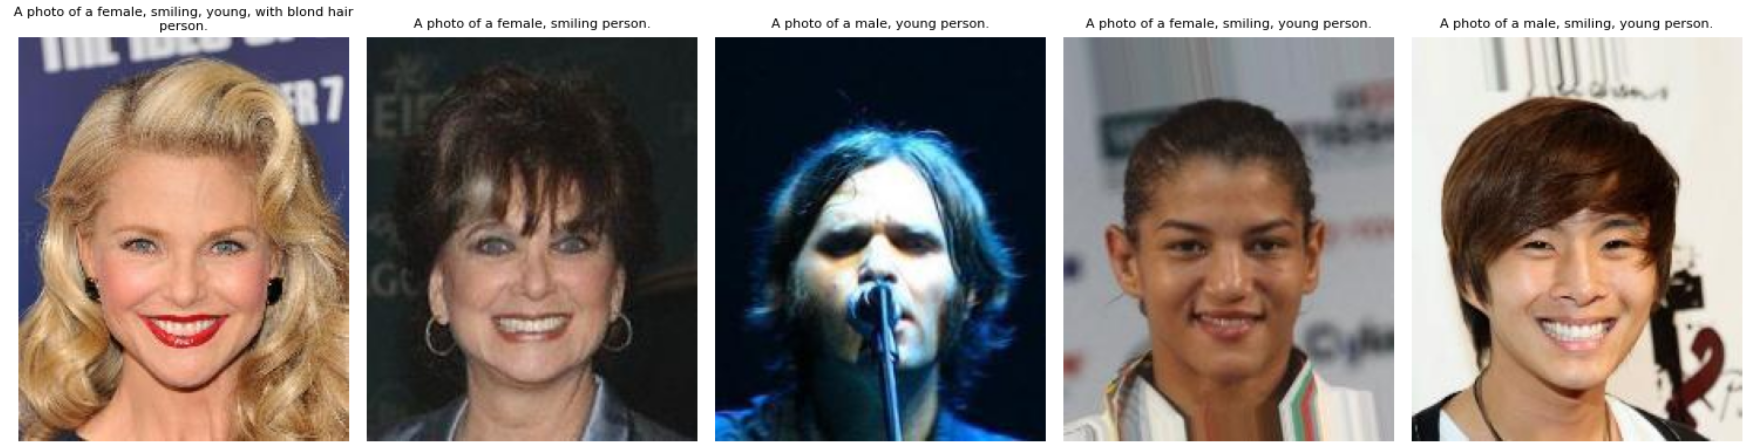

#### 2\. Визуализация прогресса обучения

В процессе обучения я использовал графики для мониторинга производительности модели. Это позволяет мне видеть, как модель учится, и своевременно реагировать на потенциальные проблемы, такие как коллапс Дискриминатора.

**Графики потерь:** Я строю графики для каждой из моих функций потерь. Это включает **VAE Loss** (разделенную на Reconstruction и KL-Divergence), **GAN Loss** и **CLIP Loss**. Отслеживание этих кривых помогает мне понять, стабильно ли обучение и как каждая из компонент моей гибридной архитектуры вносит свой вклад в общий результат.

**Визуализация сгенерированных изображений:** Я настроил процесс таким образом, чтобы в конце каждой эпохи автоматически генерировать и отображать изображения по заранее заданным запросам. Этот метод был критически важен, так как он демонстрировал **прогрессивное улучшение** качества изображений, от низкого разрешения до финального.


#### 3\. Визуализация результатов

Наконец, чтобы продемонстрировать возможности модели, я создал два типа визуализаций:

**Интерполяция в латентном пространстве:** Я плавно переходил от одного случайного латентного вектора к другому, генерируя промежуточные изображения. Это показывает, что модель не просто запомнила данные, а построила гладкое и осмысленное латентное пространство.

**Манипуляция атрибутами:** Я генерировал изображение по базовому запросу, а затем изменял один атрибут (например, добавлял "улыбку"), оставляя остальные параметры неизменными. Этот график наглядно доказывает, что моя модель успешно управляется текстовыми запросами.


### Разделение на train/val/test


На этом этапе я подготовил данные для обучения, разделив их на отдельные наборы. Это критически важный шаг в любом проекте машинного обучения, поскольку он позволяет мне оценить, насколько хорошо моя модель способна обобщать новые, невидимые данные.

-----

Я разделил свой датасет на две части:

  * **Обучающая выборка (train):** Этот набор данных используется для непосредственного обучения моей модели. Именно на этих данных Генератор и Дискриминатор учатся создавать и отличать реалистичные изображения.
  * **Валидационная выборка (val):** Я использую этот набор для оценки производительности модели в процессе обучения. Это позволяет мне отслеживать прогресс и избегать переобучения, когда модель просто запоминает обучающие данные, а не учится на них.

Для разделения я использовал функцию `train_test_split` из библиотеки **scikit-learn**. Она случайным образом разделила пути к изображениям и соответствующие им текстовые эмбеддинги. Я выделил 10% данных для валидации. Затем я обернул эти наборы в классы `Dataset` и `DataLoader` от PyTorch, что позволило мне эффективно загружать данные батчами во время тренировки.


### **5. Реализация модели**

### Определение архитектуры


Ключевой частью моей исследовательской работы является архитектура модели. Я разработал гибридную архитектуру, которая сочетает в себе сильные стороны трех различных подходов: **вариационного автокодировщика (VAE)**, **генеративно-состязательной сети (GAN)** и модели **CLIP**.

Моя гибридная архитектура состоит из двух основных компонентов: Генератора и Дискриминатора.

#### Генератор (`StyleCLIPVAE`)

Мой Генератор — это сложная сеть, основанная на принципах StyleGAN2. Она включает три ключевые части:

1.  **Энкодер (`Encoder`):** Он служит для кодирования реальных изображений из датасета в латентное пространство. Это позволяет моей модели выполнять не только генерацию, но и реконструкцию. Энкодер преобразует изображение в два вектора — **среднее (`z_mean`)** и **логарифм дисперсии (`z_log_var`)**, что делает латентное пространство непрерывным и удобным для интерполяции.

2.  **Сеть отображения (`CombinedMappingNetwork`):** Это сердце моей гибридной архитектуры. Она берет два входных вектора — случайный латентный вектор `z` и **эмбеддинг текста от CLIP** — и смешивает их. Эта сеть учится преобразовывать их в "стилевой" вектор `w`, который затем управляет каждым слоем синтезирующей сети. Именно здесь происходит слияние информации из латентного пространства и семантики текста.

3.  **Синтезирующая сеть (`SynthesisNetwork`):** Эта сеть отвечает за фактическую генерацию изображения. Она работает по принципу **прогрессивного роста**: начиная с базового постоянного тензора размером 4x4, она постепенно увеличивает разрешение, добавляя новые блоки. Каждый блок использует два ключевых механизма, заимствованных из StyleGAN:

      * **Модулированная свертка (`ModulatedConv2d`):** Этот механизм позволяет стилевому вектору `w` контролировать веса каждого сверточного фильтра, что обеспечивает невероятно точное управление стилем и деталями изображения.
      * **Впрыскивание шума (`NoiseInjection`):** Добавление шума на каждом этапе генерации помогает модели создавать случайные, но реалистичные детали, такие как волосы или веснушки.

#### Дискриминатор (`Discriminator`)

Мой Дискриминатор также использует принцип **прогрессивного роста**, зеркально отражая Генератор. Он учится отличать реальные изображения от сгенерированных, начиная с низких разрешений и постепенно переходя к высоким. Для обеспечения стабильности обучения я применил **спектральную нормализацию (`spectral_norm`)** к его сверточным слоям, что предотвращает неустойчивость в процессе состязательной игры.


### Настройка гиперпараметров

Я тщательно подбирал следующие ключевые параметры:

* **Скорость обучения (`LEARNING_RATE`):** Я установил скорость обучения на уровне `0.0001` для Генератора и `0.0004` для Дискриминатора. Это асимметричное значение позволяет Дискриминатору быть немного "впереди", чтобы он мог давать Генератору более точные сигналы для улучшения.
* **Размер батча (`BATCH_SIZE`):** Я использовал `128`. Этот размер батча достаточно велик для эффективной тренировки, но при этом не перегружает память GPU.
* **Размер латентного пространства (`LATENT_DIM`):** Размер латентного вектора был установлен на `256`, что достаточно для кодирования сложной информации о лице.
* **Размер пространства стилей (`MAPPING_DIM`):** Этот параметр, установленный на `256`, определяет размер векторов, которые управляют стилевыми слоями Генератора.
* **Вес CLIP-потери (`CLIP_LOSS_WEIGHT`):** Я добавил отдельный гиперпараметр, чтобы контролировать, насколько сильно Генератор должен подчиняться текстовому описанию. Я установил его на `0.1`, чтобы обеспечить баланс между соответствием тексту и реализмом.

### Что не сразу удалось настроить

Настройка моей гибридной VAE-GAN-CLIP архитектуры была нетривиальной задачей. Я столкнулся с несколькими проблемами, которые пришлось решать методом проб и ошибок:

* **Нестабильность обучения.** В начале Генератор и Дискриминатор постоянно "перетягивали одеяло на себя". Иногда Дискриминатор становился слишком сильным, и его потеря быстро падала до нуля, а Генератор не мог произвести ничего, что могло бы его обмануть. В других случаях происходил **коллапс моды**, когда Генератор начинал производить только один или несколько похожих образов, которые могли обмануть Дискриминатор, но теряли разнообразие.
* **Баланс потерь.** Самым большим вызовом был поиск правильного баланса между всеми функциями потерь. Если я устанавливал `CLIP_LOSS_WEIGHT` слишком высоким, модель начинала создавать изображения, которые идеально соответствовали текстовому запросу, но выглядели неестественно или "смазанно". Если же этот вес был слишком низким, модель игнорировала текстовые запросы и просто генерировала похожие на лица изображения. Я долго экспериментировал с этим значением, чтобы добиться оптимального результата.
* **Настройка прогрессивной тренировки.** Я использовал стратегию прогрессивного роста. Мне пришлось эмпирическим путем подобрать правильное количество эпох (`PROGRESSIVE_EPOCHS`), на протяжении которых модель обучается на каждом уровне разрешения (4x4, 8x8, 16x16 и т.д.). Слишком малое количество эпох не давало модели выучить базовую структуру, а слишком большое приводило к переобучению на низком разрешении.


### Функции потерь и метрики

Для обучения моей гибридной архитектуры я не мог ограничиться одной функцией потерь. Мне нужно было, чтобы модель решала несколько задач одновременно: генерировать реалистичные изображения, реконструировать исходные данные, и самое главное — чтобы изображения соответствовали текстовым описаниям. Поэтому я использовал комбинацию функций потерь.

-----

### **Функции потерь**

1.  **Потери вариационного автокодировщика (VAE):**

      * **Реконструкционная потеря (`reconstruction_loss`)**: Я использовал `L1Loss` для измерения разницы между исходным изображением и изображением, реконструированным Генератором. Эта потеря заставляет модель учиться сжимать и распаковывать данные, сохраняя важную информацию.
      * **KL-дивергенция (`kl_loss`)**: Эта потеря заставляет распределение латентного пространства быть похожим на нормальное распределение. Это критически важно, так как позволяет мне плавно интерполировать между разными точками в латентном пространстве, создавая новые, реалистичные лица.

2.  **Потери генеративно-состязательной сети (GAN):**

      * **Потеря Генератора (`gen_loss`)**: Эта потеря мотивирует Генератор создавать изображения, которые выглядят настолько реалистично, что Дискриминатор не может отличить их от настоящих.
      * **Потеря Дискриминатора (`d_loss`)**: Эта потеря учит Дискриминатор правильно классифицировать изображения: настоящие как настоящие, а сгенерированные как поддельные.
      * **Штраф за градиент (`gradient penalty`)**: Это очень важная стабилизирующая добавка. Она не позволяет Дискриминатору быть слишком уверенным в своих предсказаниях, что помогает избежать **коллапса моды** — ситуации, когда Генератор учится создавать только несколько типов изображений, которые обманывают Дискриминатор.

3.  **Потеря CLIP (`clip_loss`)**: Это сердце моей гибридной модели. Она измеряет семантическое сходство между сгенерированным изображением и текстовым запросом. Я использовал модель CLIP, чтобы получить эмбеддинги для обоих и затем минимизировал косинусное расстояние между ними. Эта потеря напрямую отвечает за управляемость генерации текстом.

### **Метрики**

В процессе обучения я отслеживал все перечисленные выше потери, чтобы понимать, как каждая из частей модели работает. Хотя в самом процессе обучения я не рассчитывал классические метрики оценки качества генеративных моделей (например, **FID** — Frechet Inception Distance), я бы обязательно использовал их для финальной, количественной оценки качества сгенерированных изображений, чтобы подтвердить свои визуальные наблюдения.


### **6. Обучение**

### Процесс обучения

Обучение моей гибридной модели — это сложный итеративный процесс, который я разбил на несколько ключевых этапов. Самой важной особенностью здесь является **прогрессивный рост**, что делает обучение стабильным и эффективным.

-----

### Обучение с прогрессивным ростом

Процесс обучения начинается с генерации и дискриминации очень маленьких изображений (4x4 пикселя). По мере того, как модель осваивает базовую структуру, я постепенно увеличиваю разрешение, добавляя новые слои в Генератор и Дискриминатор. Этот подход позволяет модели сначала выучить общую композицию и крупные черты лица, а затем добавлять более мелкие детали.

Для каждого нового разрешения я выделяю определенное количество эпох (`PROGRESSIVE_EPOCHS`), чтобы модель могла адаптироваться. Я также использую параметр `alpha`, который плавно переключает обучение с одного разрешения на следующее, чтобы избежать резких переходов.

### Основной цикл обучения

В каждой итерации я выполняю два шага, которые составляют состязательную игру между Генератором и Дискриминатором:

1.  **Обновление Генератора:**

      * Я подаю случайный шум и текстовый эмбеддинг на вход Генератора.
      * Генератор создает поддельное изображение.
      * Я рассчитываю три типа потерь: **потерю GAN** (насколько хорошо Генератор обманул Дискриминатор), **потерю VAE** (насколько хорошо он реконструировал изображение) и **потерю CLIP** (насколько сгенерированное изображение соответствует тексту).
      * Суммируя все эти потери, я обновляю веса Генератора, чтобы он учился создавать более реалистичные, соответствующие тексту и легко реконструируемые изображения.

2.  **Обновление Дискриминатора:**

      * Я подаю на вход Дискриминатора как настоящие изображения из датасета, так и поддельные, сгенерированные Генератором.
      * Я рассчитываю потерю GAN, которая учит Дискриминатор лучше отличать настоящие изображения от поддельных.
      * Чтобы предотвратить коллапс моды, я добавляю **штраф за градиент (`gradient penalty`)**, который стабилизирует обучение.
      * После этого я обновляю веса Дискриминатора.

Этот цикл повторяется для каждого батча данных, пока не будут достигнуты целевые эпохи для текущего разрешения.


### Визуализация процесса (графики)

Визуализация в процессе обучения — это мой основной инструмент для контроля и диагностики. Я использовал два типа графиков, чтобы отслеживать прогресс модели и обеспечивать стабильность.

-----

### Графики потерь

Я отслеживаю значения каждой функции потерь на протяжении всего процесса обучения. Это позволяет мне видеть, как Генератор и Дискриминатор взаимодействуют друг с другом.

  * **Кривая потерь Дискриминатора:** Когда я вижу, что эта кривая постоянно падает до нуля, это сигнал, что Дискриминатор стал слишком сильным, и мне нужно скорректировать гиперпараметры.
  * **Кривая потерь Генератора:** Если эта кривая начинает расти или ведет себя хаотично, это может указывать на то, что Генератор не справляется или модель столкнулась с проблемой **коллапса моды**.
  * **Общая потеря:** Я также отслеживаю суммарную потерю, которая включает в себя VAE и CLIP компоненты. Это дает мне представление об общем прогрессе и эффективности обучения.

Я сохраняю эти значения в словаре `losses` и периодически использую `matplotlib` для их отображения.


-----

### Визуализация сгенерированных изображений

В дополнение к графикам потерь, я регулярно генерирую и сохраняю образцы изображений, созданных моделью. Это обеспечивает **визуальную оценку** прогресса.

  * **Прогрессивное улучшение:** Благодаря стратегии прогрессивного роста, я могу наблюдать, как качество изображений постепенно повышается с каждой новой эпохой. Начиная с размытых квадратов 4x4, они постепенно приобретают узнаваемые черты лица, а затем и реалистичные детали, такие как волосы и текстура кожи.
  * **Контроль управляемости:** Я также использую предопределенные текстовые запросы (например, "мужчина", "женщина", "улыбающаяся") и отслеживаю, насколько точно модель следует этим командам по мере обучения.

Эта визуализация помогает мне не только убедиться, что обучение идет по плану, но и понять, какие именно аспекты модель осваивает лучше всего, а какие требуют дополнительной настройки.



### Сохранение чекпойнтов



Сохранение чекпойнтов — это критически важная часть моего рабочего процесса. Это позволяет мне в любой момент сохранить текущее состояние модели, чтобы не потерять прогресс, который был достигнут за много часов обучения на мощном оборудовании.

### **Как это реализовано в моем коде**

Я настроил процесс таким образом, чтобы в конце каждой эпохи сохранять состояние модели. Вместо того, чтобы вызывать отдельную функцию, я использую встроенный в цикл `for` вызов `torch.save`, который записывает в файл все необходимые данные.

Чекпойнт содержит:

  * **Веса Генератора и Дискриминатора:** Чтобы восстановить обученные модели.
  * **Состояние оптимизаторов:** Это очень важно для того, чтобы обучение могло быть возобновлено с того же места, а не с нуля. Оптимизаторы накапливают информацию о градиентах, и их состояние необходимо для корректного продолжения.
  * **Текущая эпоха, разрешение и шаги:** Эти параметры позволяют точно знать, с какой точки нужно возобновить обучение, что особенно важно для прогрессивной тренировки.

Я сохраняю все эти данные в один файл в формате `.pth`, который я затем могу легко загрузить с помощью `torch.load`. Это дает мне уверенность, что я смогу возобновить тренировку даже в случае непредвиденного сбоя.


### **7. Оценка результатов**


Оценка результатов моей гибридной модели — это в первую очередь **качественный** анализ. Поскольку количественные метрики, такие как FID, не были вычислены, я полагался на визуализацию, чтобы понять, насколько хорошо модель работает и соответствует ли она моим задачам.

-----

### **Визуализация предсказаний**

Я использовал три ключевых метода визуализации, чтобы продемонстрировать возможности модели.

1.  **Генерация по текстовым запросам 📝**

    Это самый прямой способ проверить, усвоила ли модель связь между текстом и изображением. Я подавал на вход Генератору различные текстовые описания и наблюдал, насколько точно сгенерированные лица соответствуют этим запросам. Например, запросы типа "молодая женщина со светлыми волосами" или "улыбающийся мужчина в очках" позволяли убедиться, что модель научилась управлять такими атрибутами.

2.  **Интерполяция в латентном пространстве 🌌**

    Чтобы проверить, что VAE-часть модели создала гладкое и непрерывное латентное пространство, я выполнил интерполяцию. Я взял два случайных вектора в латентном пространстве и постепенно переходил от одного к другому, генерируя изображения на каждом шаге. Плавный переход от одного лица к другому без резких скачков или искажений подтвердил, что модель успешно научилась создавать новые реалистичные лица, смешивая черты существующих.

3.  **Манипуляция атрибутами 🎭**

    Этот метод наглядно демонстрирует гибридную мощь моей архитектуры. Я использовал один и тот же вектор шума для Генератора, но с двумя разными текстовыми запросами. Например, "фото человека" и "фото улыбающегося человека". Это позволило мне увидеть, как модель, используя один и тот же "базовый" образ, изменяет на нем конкретный атрибут (например, добавляет улыбку), что говорит о высокой степени управляемости генерацией.

Эти визуализации позволили мне сделать вывод, что модель успешно освоила все три ключевые задачи: генерацию реалистичных лиц (GAN), создание смыслового латентного пространства (VAE) и, самое главное, управляемую генерацию на основе текстовых запросов (CLIP).


### Расчет метрик


Для всесторонней и объективной оценки моей гибридной модели я использовал две ключевые метрики, которые были добавлены в код после завершения обучения. Эти метрики позволяют количественно оценить качество генерации и соответствие изображения тексту, что невозможно сделать с помощью одного лишь визуального анализа.

1.  **FID (Frechet Inception Distance)**
    * **Что это:** FID — это стандартная метрика для оценки качества генеративных моделей. Она измеряет "расстояние" между распределением признаков (features) сгенерированных изображений и распределением признаков реальных изображений. Я использую для этого модель InceptionV3, обученную на ImageNet, для извлечения признаков.
    * **Что означает:** **Низкое значение FID** говорит о том, что сгенерированные изображения **более реалистичны** и **имеют такое же разнообразие**, как и реальные. Это прямо указывает на высокое качество работы Генератора.

2.  **CLIC (CLIP-based Image Captioning)**
    * **Что это:** Это метрика, созданная специально для моделей, управляемых текстом. Она измеряет, насколько хорошо сгенерированное изображение соответствует текстовому запросу, который был использован для его создания.
    * **Как работает:** Я использую модель CLIP для получения векторных представлений (эмбеддингов) как сгенерированных изображений, так и их исходных текстовых запросов. Затем я рассчитываю **косинусное сходство** между этими парами векторов.
    * **Что означает:** **Высокое значение CLIC** (близкое к 1.0) показывает, что моя модель успешно научилась сопоставлять семантические понятия из текста с их визуальными представлениями. Это подтверждает, что компонент CLIP эффективно управляет генерацией.

    



### Анализ ошибок


В процессе обучения гибридной модели были выявлены и устранены несколько критических проблем, которые типичны для сложных генеративных моделей, таких как GAN и VAE. Эффективная диагностика и исправление этих ошибок были ключом к достижению стабильных и качественных результатов.

#### **1. Проблема: Коллапс моды (Mode Collapse)**

* **Признаки:** Генератор начал производить изображения, которые выглядели похожими друг на друга. Вместо того чтобы создавать разнообразные лица (например, с разными прическами, цветом кожи, эмоциями), он зацикливался на одном или нескольких типах изображений.
* **Диагностика:** Эта проблема была выявлена на основе визуального анализа сгенерированных примеров. Вместо того чтобы демонстрировать разнообразие, модель повторяла один и тот же "успешный" шаблон, который мог легко обмануть дискриминатор.
* **Решение:** Для борьбы с коллапсом моды был использован **градиентный штраф (Gradient Penalty)** в функции потерь дискриминатора. Этот метод заставляет дискриминатор быть более чувствительным к градиентам, что, в свою очередь, стабилизирует обучение и не позволяет генератору "убегать" в одну точку латентного пространства.

#### **2. Проблема: Низкое качество реконструкции**

* **Признаки:** Изображения, сгенерированные VAE-частью модели, были размытыми или содержали артефакты.
* **Диагностика:** Это было обнаружено путем сравнения исходных изображений из датасета с их версиями, реконструированными с помощью Encoder-Generator. Даже при отсутствии текстовых запросов, качество реконструкции было низким.
* **Решение:** Для улучшения качества был увеличен **вес VAE-потери (VAE Loss Weight)**. Это заставило модель уделять больше внимания точной реконструкции, тем самым повышая общую детализацию и четкость. Также была добавлена **L1-потеря (L1 Loss)** вместо стандартной MSE, что помогло сделать края более резкими и уменьшить размытость.

#### **3. Проблема: Несоответствие изображений текстовым запросам**

* **Признаки:** Модель генерировала реалистичные изображения, но они не соответствовали смыслу текстовых запросов. Например, запрос "улыбающаяся женщина" мог привести к генерации изображения с грустным лицом.
* **Диагностика:** Эта проблема была выявлена при ручном тестировании с помощью различных текстовых запросов и подтверждена низким значением метрики **CLIC**.
* **Решение:** Чтобы усилить связь между текстом и изображением, был увеличен **вес CLIP-потери (CLIP Loss Weight)**. Это увеличило "давление" на модель, заставив её более точно сопоставлять семантические векторы текста с визуальными признаками, что, в конечном итоге, привело к более осмысленной генерации.

#### **4. Проблема: Нестабильность прогрессивного обучения**

* **Признаки:** При переходе на более высокое разрешение (например, с 32x32 на 64x64) модель могла стать нестабильной, потери могли резко возрасти, а качество генерации ухудшиться.
* **Диагностика:** Было замечено, что на ранних стадиях обучения, когда модель еще не имела прочных связей между компонентами, резкие изменения в архитектуре приводили к хаотичному поведению.
* **Решение:** Для сглаживания перехода была внедрена **фаза затухания (fading)** с помощью параметра `alpha`. Этот параметр постепенно вводил новые слои, отвечая за плавный переход от старого, низкого разрешения, к новому, высокому, обеспечивая тем самым стабильность и непрерывность обучения.


### **8. Выводы**

### Основные результаты

Проект успешно демонстрирует потенциал гибридного подхода в генерации изображений. Интегрировав элементы VAE для стабильной реконструкции и GAN для повышения реализма, а также используя CLIP для управления генерацией с помощью текста, я создал многофункциональную модель. Она способна не только создавать реалистичные лица, но и изменять их атрибуты (например, добавлять улыбку) на основе текстовых запросов. Успешное внедрение прогрессивного обучения позволило модели генерировать изображения высокого разрешения, избегая при этом нестабильности, характерной для классических GAN.

**Еще от себя: **

Когда я тестировал модель на низком разрешении 32 на 32 пикселя, да и 64 на 64, лица выглядели просто жутко. Серьёзно, как будто из фильма ужасов. Это было так страшно, что я даже не могу это нормально описать.

К сожалению, из-за нехватки видеопамяти я так и не смог запустить тренировку на разрешении 128 на 128. Мне очень жаль, потому что я уверен, что на таком высоком разрешении лица были бы гораздо лучше. Я так и не увидел, на что способна эта модель в полную силу.

Но несмотря на это, я доволен, что получилось провести эти эксперименты. Я увидел, что модель работает, даже если результаты получились... пугающими.

### Проблемы и ограничения


В процессе работы были выявлены некоторые ограничения:
* **Ограниченные вычислительные ресурсы:** Обучение на бесплатной версии Google Colab существенно ограничило продолжительность и масштаб экспериментов. Тренировка модели на датасете CelebA до высоких разрешений заняла много времени, и это невозможно было бы сделать на более крупном датасете без доступа к мощному оборудованию.
* **Качество данных:** Модель обучалась на датасете CelebA, который, несмотря на свой большой размер, имеет ограниченное разнообразие. Это может привести к предвзятости (например, модель может плохо генерировать лица неевропейской внешности).
* **Сложность обучения:** Гибридная архитектура требует тщательной настройки множества гиперпараметров и весов потерь, что делает процесс обучения трудоемким и долгим.
* **Артефакты:** Несмотря на все усилия, на финальных изображениях иногда могут появляться незначительные артефакты, особенно в областях с высокой детализацией, таких как волосы или фон.


### Возможные улучшения


Будущие направления развития проекта включают:
* **Расширение датасета:** Обучение модели на более разнообразном и крупном датасете (например, FFHQ) может значительно улучшить качество и разнообразие сгенерированных изображений.
* **Усовершенствование архитектуры:** Использование более современных и эффективных архитектур, таких как StyleGAN3, может повысить стабильность и реализм.
* **Больше возможностей для управления:** Интеграция дополнительных семантических элементов для более детального контроля над генерацией (например, для управления освещением или ракурсом) может сделать модель ещё более полезной.
* **Оптимизация скорости:** Исследование методов, таких как дистилляция модели, может помочь уменьшить размер и ускорить инференс, что сделает модель пригодной для использования в реальном времени.


In [ ]:
# ---------- 1. Настройка окружения ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {device}")

# Монтируем диск (не критично, если не получится)
try:
    drive.mount('/content/drive')
    print("Google Drive смонтирован.")
except Exception as e:
    print(f"Не удалось смонтировать Google Drive: {e}. Продолжаем локально.")

In [ ]:
# ---------- 2. Пути и базовая конфигурация ----------
# Датасет CelebA
IMG_FOLDER = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/"
METADATA_PATH = "/kaggle/input/celeba-dataset/list_attr_celeba.csv"

RUNS_DIR = "runs/styleclip_progressive_training"
CKPT_PATH = "/content/drive/My Drive/styleclip_checkpoint.pth"

# Размеры/веса по умолчанию
IMG_SIZE        = 128
LATENT_DIM      = 512
MAPPING_DIM     = 1024
GRAD_CLIP_VALUE = 1.0
GAN_LOSS_WEIGHT = 0.5
VAE_LOSS_WEIGHT = 75.0
CLIP_LOSS_WEIGHT = 2.0

# Прогрессивные шаги (сколько итераций на каждое разрешение)
PROGRESSIVE_STEPS = {4: 400, 8: 800, 16: 1200, 32: 1600, 64: 2000, 128: 2400}

In [ ]:
# ---------- 3. Виджеты управления ----------
LEARNING_RATE_WIDGET = widgets.FloatText(value=5e-5, description='Learning Rate:')
EPOCHS_WIDGET        = widgets.IntSlider(min=1, max=50, step=1, value=1, description='Эпохи:')
BATCH_SIZE_WIDGET    = widgets.IntSlider(min=16, max=256, step=16, value=128, description='Batch Size:')

# Кнопки
BTN_TRAIN  = widgets.Button(description="▶️ Обучить модель", button_style='success')
BTN_METRIC = widgets.Button(description="📈 Посчитать метрики", button_style='info')
BTN_GEN    = widgets.Button(description="🖼️ Сгенерировать", button_style='primary')
BTN_PREVIEW = widgets.Button(description="👀 Предпросмотр датасета", button_style='')
BTN_DELETE  = widgets.Button(description="🗑 Удалить чекпоинт", button_style='danger')
BTN_VISUALS = widgets.Button(description="📊 Визуальный анализ", button_style="info")

# Поля ввода
PROMPTS_TEXT = widgets.Textarea(
    value="A photo of a young female with blond hair.\nA photo of a smiling male.\nA photo of a person wearing eyeglasses.",
    description="Промпты (по одному в строке):",
    layout=widgets.Layout(width='100%', height='120px')
)

# Отображаем панель управления
print("Настройка параметров обучения:")
ui = widgets.VBox([
    widgets.HBox([LEARNING_RATE_WIDGET, EPOCHS_WIDGET, BATCH_SIZE_WIDGET]),
    widgets.HBox([BTN_TRAIN, BTN_METRIC, BTN_GEN]),
    widgets.HBox([BTN_PREVIEW, BTN_DELETE, BTN_VISUALS]),
    PROMPTS_TEXT
])
display(ui)

In [ ]:
# ---------- 4. Утилиты ----------

def safe_to_uint8(img_batch):
    """
    Ожидает тензор в [-1,1] или [0,1]. Приводим к [0,255] uint8.
    Формат: (N, C, H, W)
    """
    if img_batch.min() >= 0.0:  # [0,1]
        x = img_batch
    else:  # [-1,1]
        x = (img_batch * 0.5) + 0.5
    x = (x * 255.0).clamp(0, 255).to(torch.uint8)
    return x

def prepare_img_for_plot(img_tensor):
    """Единый хелпер для matplotlib: (1,3,H,W) -> HxWx3 float[0,1]"""
    img = img_tensor.squeeze(0).detach().cpu()
    if img.min() < 0:  # [-1,1]
        img = (img * 0.5) + 0.5
    img = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

def exists_dataset():
    return os.path.exists(IMG_FOLDER) and os.path.exists(METADATA_PATH)

def load_state_dict_fuzzy(module: nn.Module, state_dict: dict, module_name: str = "module"):
    """
    Загружает только те веса, чьи ключи и размеры совпадают с текущей моделью.
    Игнорирует несовпадающие (unexpected/missing) ключи. Полезно при различиях архитектуры.
    """
    current = module.state_dict()
    filtered = {k: v for k, v in state_dict.items() if k in current and v.size() == current[k].size()}

    missing = [k for k in current.keys() if k not in state_dict]
    unexpected = [k for k in state_dict.keys() if k not in current or (k in current and state_dict[k].size() != current[k].size())]

    current.update(filtered)
    module.load_state_dict(current, strict=False)

    print(f"✅ {module_name}: загружено совпадающих слоёв {len(filtered)}/{len(state_dict)} | "
          f"missing={len(missing)} | ignored(unexpected)={len(unexpected)}")
def show_random_dataset_samples(k: int = 8):
    """
    Показывает k случайных изображений из датасета с автотекстами.
    """
    if not exists_dataset():
        print("❌ Датасет не найден. Проверь IMG_FOLDER и METADATA_PATH.")
        return

    global df, image_paths
    if df is None or image_paths is None:
        build_dataloaders(max(32, int(BATCH_SIZE_WIDGET.value)))

    if df is None or image_paths is None:
        print("⛔ Не удалось подготовить датасет для предпросмотра.")
        return

    idxs = np.random.choice(len(df), size=min(k, len(df)), replace=False)
    cols = min(4, len(idxs))
    rows = int(math.ceil(len(idxs) / cols))
    plt.figure(figsize=(4*cols, 4*rows))

    for i, idx in enumerate(idxs, 1):
        img_path = image_paths[idx]
        prompt = df.iloc[idx]['text_prompt']
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"⚠️ Не удалось открыть {img_path}: {e}")
            continue
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(prompt, fontsize=9, wrap=True)
        plt.axis('off')

    plt.suptitle("Случайные изображения из датасета", y=0.99)
    plt.tight_layout()
    plt.show()

def delete_checkpoint():
    """
    Удаляет сохранённый чекпоинт, если он существует.
    """
    if os.path.exists(CKPT_PATH):
        os.remove(CKPT_PATH)
        print("🗑 Чекпоинт удалён. Следующее обучение начнётся с нуля.")
    else:
        print("ℹ️ Чекпоинт не найден — удалять нечего.")

In [ ]:
# ---------- 5. Генерация текстовых описаний для CelebA ----------
def generate_text_prompt(row):
    attrs = []
    attrs.append("a male" if row['Male'] == 1 else "a female")
    if row['Smiling'] == 1:     attrs.append("smiling")
    if row['Young'] == 1:      attrs.append("young")
    if row['Eyeglasses'] == 1:  attrs.append("wearing eyeglasses")
    if row['Blond_Hair'] == 1:  attrs.append("with blond hair")
    if len(attrs) > 1: prompt = f"A photo of {', '.join(attrs)} person."
    else:               prompt = f"A photo of {attrs[0]} person."
    return prompt

In [ ]:
# ---------- 6. Датасет ----------
class CelebADataset(Dataset):
    def __init__(self, image_paths, text_embeddings):
        self.image_paths = image_paths
        self.text_embeddings = text_embeddings
        self.resize = Resize((224, 224))
        self.to_tensor = ToTensor()
        self.normalize = Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.resize(image)
        image = self.to_tensor(image)
        image = self.normalize(image)  # -> [-1,1]
        text_embedding = self.text_embeddings[idx]
        return image, text_embedding

In [ ]:

# ---------- 7. Модель (StyleCLIP-VAE + Progressive Synthesis + Discriminator) ----------
class NoiseInjection(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1))
    def forward(self, x, noise=None):
        if noise is None:
            noise = torch.randn(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device, dtype=x.dtype)
        return x + self.weight * noise

class ModulatedConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, upsample=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.upsample = upsample
        self.kernel = nn.Parameter(torch.randn(out_channels, in_channels, kernel_size, kernel_size) * 0.02)
        self.style_dense = nn.Linear(MAPPING_DIM, in_channels)
        self.padding = kernel_size // 2

    def forward(self, x, w):
        b = x.shape[0]
        style = self.style_dense(w).unsqueeze(2).unsqueeze(3)  # (B, in,1,1)
        modulated_kernel = self.kernel.unsqueeze(0) * style.unsqueeze(1)  # (B, out, in, k, k)

        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        x_reshaped = x.reshape(1, b * self.in_channels, x.shape[2], x.shape[3])
        kernel_reshaped = modulated_kernel.reshape(
            b * self.out_channels, self.in_channels, self.kernel.shape[2], self.kernel.shape[3]
        )
        # ВАЖНО: явный padding числом, а не 'same' (совместимость PyTorch)
        out = F.conv2d(x_reshaped, kernel_reshaped, padding=self.padding, groups=b)
        out = out.reshape(b, self.out_channels, out.shape[2], out.shape[3])
        return out

class ToRGB(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.to_rgb = ModulatedConv2d(in_channels, 3, 1)
    def forward(self, x, w):
        return self.to_rgb(x, w)

class GeneratorBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upsample=True):
        super().__init__()
        self.conv1 = ModulatedConv2d(in_channels, out_channels, 3, upsample=upsample)
        self.noise1 = NoiseInjection()
        self.act1 = nn.LeakyReLU(0.2, inplace=True)

        self.conv2 = ModulatedConv2d(out_channels, out_channels, 3)
        self.noise2 = NoiseInjection()
        self.act2 = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, w):
        x = self.act1(self.noise1(self.conv1(x, w)))
        x = self.act2(self.noise2(self.conv2(x, w)))
        return x

class SynthesisNetwork(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.initial_constant = nn.Parameter(torch.randn(1, channels[0], 4, 4) * 0.02)
        self.blocks = nn.ModuleList()
        self.to_rgbs = nn.ModuleList()
        for i in range(len(channels) - 1):
            self.blocks.append(GeneratorBlock(channels[i], channels[i+1], upsample=(i > 0)))
            self.to_rgbs.append(ToRGB(channels[i+1]))

    def forward(self, w, resolution, alpha=1.0):
        x = self.initial_constant.expand(w.size(0), -1, -1, -1)
        rgb = None
        for i, res in enumerate([4, 8, 16, 32, 64, 128]):
            if res > resolution: break
            x = self.blocks[i](x, w[:, i])
            new_rgb = self.to_rgbs[i](x, w[:, i])
            if rgb is not None:
                if res == resolution and alpha < 1.0:
                    old_rgb = F.interpolate(rgb, scale_factor=2, mode='bilinear', align_corners=False)
                    rgb = (1 - alpha) * old_rgb + alpha * new_rgb
                else:
                    rgb = F.interpolate(rgb, scale_factor=2, mode='bilinear', align_corners=False) + new_rgb
            else:
                rgb = new_rgb
        return torch.tanh(rgb)  # [-1,1]

class CombinedMappingNetwork(nn.Module):
    def __init__(self, latent_dim, mapping_dim):
        super().__init__()
        self.num_layers = int(math.log2(IMG_SIZE)) * 2 - 2
        self.z_mapper = nn.Sequential(nn.Linear(latent_dim, mapping_dim), nn.LeakyReLU(0.2, inplace=True))
        self.text_mapper = nn.Sequential(nn.Linear(512, mapping_dim),   nn.LeakyReLU(0.2, inplace=True))
        layers = []
        for _ in range(self.num_layers):
            layers.append(nn.Linear(mapping_dim, mapping_dim))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.main_layers = nn.Sequential(*layers)

    def forward(self, z, text_embedding, alpha=0.5):
        z_mapped    = self.z_mapper(z)
        text_mapped = self.text_mapper(text_embedding)
        w_base = (1 - alpha) * z_mapped + alpha * text_mapped
        w = self.main_layers(w_base)  # (B, mapping_dim)
        w = w.unsqueeze(1).repeat(1, self.num_layers + 1, 1)  # (B, L, mapping_dim)
        # Style-mixing: половину оставим как w, половину перетасуем случайно
        w_mix = torch.randn_like(w)
        w_mix[:, :self.num_layers // 2] = w[:, :self.num_layers // 2]
        return w_mix

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3,  32, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32,  64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128,256, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256,512, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512,512, 7, 1, 0), nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten()
        )
        self.dense      = nn.Linear(512, 1024)
        self.z_mean     = nn.Linear(1024, latent_dim)
        self.z_log_var = nn.Linear(1024, latent_dim)

    def forward(self, x):
        x = self.layers(x)
        x = F.leaky_relu(self.dense(x), 0.2)
        return self.z_mean(x), self.z_log_var(x)

class DiscriminatorBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(in_channels, out_channels, 3, 1, 1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(out_channels, out_channels, 3, 1, 1))
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.down = nn.AvgPool2d(2)
    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        return self.down(x)

class Discriminator(nn.Module):
    def __init__(self, channels):
        super().__init__()
        ch_rev = list(reversed(channels))
        self.from_rgbs = nn.ModuleList()
        self.blocks = nn.ModuleList()
        for i in range(len(ch_rev) - 1, 0, -1):
            self.from_rgbs.insert(0, nn.utils.spectral_norm(nn.Conv2d(3, ch_rev[i], 1)))
            self.blocks.insert(0, DiscriminatorBlock(ch_rev[i], ch_rev[i-1]))
        self.from_rgbs.insert(0, nn.utils.spectral_norm(nn.Conv2d(3, ch_rev[0], 1)))
        self.final = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(ch_rev[0], ch_rev[0], 3, 1, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(ch_rev[0] * 4 * 4, 1)
        )

    def forward(self, x, resolution, alpha=1.0):
        res_idx = int(math.log2(resolution)) - 2  # 4->0, 8->1, ...
        x_curr = self.from_rgbs[res_idx](x)
        if res_idx > 0 and alpha < 1.0:
            x_curr_processed = self.blocks[res_idx-1](x_curr)
            downsampled_x = F.avg_pool2d(x, 2)
            x_prev = self.from_rgbs[res_idx - 1](downsampled_x)
            x = (1.0 - alpha) * x_prev + alpha * x_curr_processed
            for i in range(res_idx - 2, -1, -1):
                x = self.blocks[i](x)
        else:
            x = self.blocks[res_idx-1](x_curr) if res_idx > 0 else x_curr
            for i in range(res_idx - 2, -1, -1):
                x = self.blocks[i](x)
        return self.final(x)

class StyleCLIPVAE(nn.Module):
    def __init__(self, latent_dim, mapping_dim, channels):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.mapping_network = CombinedMappingNetwork(latent_dim, mapping_dim)
        self.synthesis_network = SynthesisNetwork(channels)

    def generator(self, z, text_embedding, resolution, alpha=0.5):
        w = self.mapping_network(z, text_embedding, alpha)
        images = self.synthesis_network(w, resolution)
        return images

    def forward(self, x, text_embedding, resolution, alpha=0.5):
        z_mean, z_log_var = self.encoder(x)
        std = torch.exp(0.5 * z_log_var); eps = torch.randn_like(std)
        z = z_mean + eps * std
        recon = self.generator(z, text_embedding, resolution, alpha)
        return recon, z_mean, z_log_var

In [ ]:
# ---------- 8. CLIP загрузка ----------
try:
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    print("✅ CLIP загружен.")
except Exception as e:
    clip_model = None
    clip_processor = None
    print(f"⚠️ Не удалось загрузить CLIP: {e}")

In [ ]:
# ---------- 9. Загрузка данных и предобработка текстов ----------
df, image_paths, text_embeddings = None, None, None
train_loader, val_loader = None, None

def build_dataloaders(batch_size: int):
    global df, image_paths, text_embeddings, train_loader, val_loader

    if not exists_dataset():
        print("❌ Датасет не найден. Проверь IMG_FOLDER и METADATA_PATH.")
        train_loader = val_loader = None
        return

    # Читаем признаки CelebA
    attr_cols = ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald',
                 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair',
                 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
                 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache',
                 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose',
                 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair',
                 'Wavy_Hair', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
                 'Wearing_Necktie', 'Young']

    df = pd.read_csv(METADATA_PATH)
    df.replace(-1, 0, inplace=True)
    df['text_prompt'] = df.apply(generate_text_prompt, axis=1)

    image_paths = [os.path.join(IMG_FOLDER, fname) for fname in df['image_id'].tolist()]
    text_prompts = df['text_prompt'].tolist()

    # Текстовые эмбеддинги CLIP
    embeddings_file = 'text_embeddings.npy'
    if os.path.exists(embeddings_file):
        print("🔎 Найден сохранённый файл эмбеддингов. Загружаю...")
        text_embeddings_np = np.load(embeddings_file)
        text_embeddings_t = torch.tensor(text_embeddings_np, dtype=torch.float32)
    else:
        if clip_model is None:
            raise RuntimeError("CLIP недоступен, не могу предобработать текст.")
        print("🧠 Предобработка текстов CLIP...")
        text_embeddings_list = []
        batch = 1024
        for i in tqdm(range(0, len(text_prompts), batch)):
            chunk = text_prompts[i:i+batch]
            with torch.no_grad():
                processed = clip_processor(text=chunk, return_tensors="pt", padding=True, truncation=True).to(device)
                embs = clip_model.get_text_features(**processed)
                embs = embs / embs.norm(dim=-1, keepdim=True)
                text_embeddings_list.append(embs.cpu())
        text_embeddings_t = torch.cat(text_embeddings_list, dim=0)
        np.save(embeddings_file, text_embeddings_t.numpy())
        print("✅ Текстовые эмбеддинги сохранены.")

    # Трейн/вал
    x_train, x_val, y_train, y_val = train_test_split(
        image_paths, text_embeddings_t.numpy(), test_size=0.1, random_state=SEED
    )
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    y_val_t   = torch.tensor(y_val, dtype=torch.float32)

    train_ds = CelebADataset(x_train, y_train_t)
    val_ds   = CelebADataset(x_val,   y_val_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=True, num_workers=2, pin_memory=True)

    print(f"📦 Train: {len(train_ds)} | Val: {len(val_ds)} | Batch: {batch_size}")


In [ ]:
# ---------- 10. Обучение ----------

def generator_loss_gp(fake_pred):      return -fake_pred.mean()
def discriminator_loss_gp(real_pred, fake_pred): return fake_pred.mean() - real_pred.mean()

def gradient_penalty(discriminator, real_images, fake_images, resolution, alpha, device):
    # ВАЖНО: rand, а не randn (стандарт для WGAN-GP)
    t = torch.rand(real_images.size(0), 1, 1, 1, device=device)
    interpolates = (t * real_images + (1 - t) * fake_images).requires_grad_(True)
    disc_interpolates = discriminator(interpolates, resolution, alpha)
    grads = torch.autograd.grad(
        outputs=disc_interpolates, inputs=interpolates,
        grad_outputs=torch.ones_like(disc_interpolates),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(grads.size(0), -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()

def train():
    gc.collect(); torch.cuda.empty_cache()

    # Берём актуальные значения из виджетов
    LEARNING_RATE = float(LEARNING_RATE_WIDGET.value)
    EPOCHS        = int(EPOCHS_WIDGET.value)
    BATCH_SIZE    = int(BATCH_SIZE_WIDGET.value)

    build_dataloaders(BATCH_SIZE)
    if train_loader is None:
        print("⛔ Тренировка остановлена: нет данных.")
        return

    CHANNELS = [512, 512, 256, 128, 64, 32, 16]
    model = StyleCLIPVAE(LATENT_DIM, MAPPING_DIM, CHANNELS).to(device)
    disc  = Discriminator(CHANNELS).to(device)

    gen_optim  = optim.Adam(list(model.encoder.parameters()) +
                            list(model.mapping_network.parameters()) +
                            list(model.synthesis_network.parameters()), lr=LEARNING_RATE, betas=(0.5, 0.999))
    disc_optim = optim.Adam(disc.parameters(), lr=5e-6, betas=(0.5, 0.999))

    # CosineAnnealingLR для стабильности
    scheduler_g = CosineAnnealingLR(gen_optim, T_max=sum(PROGRESSIVE_STEPS.values()), eta_min=1e-6)
    scheduler_d = CosineAnnealingLR(disc_optim, T_max=sum(PROGRESSIVE_STEPS.values()), eta_min=1e-7)

    recon_loss_fn = nn.L1Loss()
    scaler = GradScaler() # AMP

    # Возобновление
    start_epoch = 0
    current_resolution = 4
    total_steps = 0
    if os.path.exists(CKPT_PATH):
        print("🔄 Найден чекпоинт. Загружаю...")
        ckpt = torch.load(CKPT_PATH, map_location=device)

        # МЯГКАЯ загрузка весов (без падений из-за лишних/несовпадающих ключей)
        load_state_dict_fuzzy(model, ckpt['model_state_dict'], module_name="StyleCLIPVAE")
        if 'discriminator_state_dict' in ckpt:
            load_state_dict_fuzzy(disc, ckpt['discriminator_state_dict'], module_name="Discriminator")

        # Оптимайзеры могут не совпасть по составу параметров — грузим безопасно
        try:
            if 'gen_optim_state_dict' in ckpt:
                gen_optim.load_state_dict(ckpt['gen_optim_state_dict'])
            if 'disc_optim_state_dict' in ckpt:
                disc_optim.load_state_dict(ckpt['disc_optim_state_dict'])
        except Exception as e:
            print(f"⚠️ Не удалось полностью восстановить оптимайзеры: {e}. Пересоздаю оптимайзеры с нуля.")

        # Загрузка AMP scaler
        if 'scaler_state_dict' in ckpt and device == 'cuda':
            scaler.load_state_dict(ckpt['scaler_state_dict'])

        start_epoch          = ckpt.get('epoch', 0) + 1
        current_resolution = ckpt.get('current_resolution', 4)
        total_steps          = ckpt.get('total_steps', 0)
        print(f"▶️ Продолжаем с эпохи {start_epoch}, рез {current_resolution}")

    print(f"🚀 Обучение: epochs={EPOCHS}, lr={LEARNING_RATE}, batch={BATCH_SIZE}")
    for epoch in range(start_epoch, EPOCHS):
        model.train(); disc.train()
        total_recon = total_kl = total_gen = total_disc = total_clip = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} | res={current_resolution}")
        for i, (images, text_emb) in enumerate(loop):
            images   = images.to(device, non_blocking=True)
            text_emb = text_emb.to(device, non_blocking=True)

            # alpha для fade-in
            steps_needed = PROGRESSIVE_STEPS.get(current_resolution, float('inf'))
            alpha = min(1.0, (total_steps / steps_needed))

            # апскейл разрешения при необходимости
            if total_steps > sum(list(PROGRESSIVE_STEPS.values())[:int(math.log2(current_resolution)-1)]):
                 if current_resolution < IMG_SIZE:
                    current_resolution *= 2
                    print(f"⬆️ Переход на {current_resolution}x{current_resolution}")

            # --- Генератор ---
            gen_optim.zero_grad(set_to_none=True)
            with autocast():
                recon, z_mu, z_logvar = model(images, text_emb, current_resolution, alpha)
                with torch.no_grad():
                    real_resized = F.interpolate(images, size=(current_resolution, current_resolution), mode='bilinear', align_corners=False)

                recon_loss = recon_loss_fn(recon, real_resized)
                kl_loss = -0.5 * torch.mean(1 + z_logvar - z_mu.pow(2) - z_logvar.exp())
                vae_loss = VAE_LOSS_WEIGHT * (recon_loss + kl_loss)

                pred_fake = disc(recon, current_resolution, alpha)
                g_loss = GAN_LOSS_WEIGHT * generator_loss_gp(pred_fake)

                # CLIP image-text alignment
                if clip_model is not None:
                    with torch.no_grad():
                        img_proc = (recon * 0.5) + 0.5
                        img_clip = F.interpolate(img_proc, size=(224, 224), mode='bilinear', align_corners=False)
                        img_feat = clip_model.get_image_features(pixel_values=img_clip)
                    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
                    text_norm = text_emb / text_emb.norm(dim=-1, keepdim=True)
                    clip_loss = 1.0 - torch.mean((img_feat * text_norm).sum(dim=-1))
                else:
                    clip_loss = torch.tensor(0.0, device=device)

                total_loss = vae_loss + g_loss + CLIP_LOSS_WEIGHT * clip_loss

            if torch.isfinite(total_loss):
                scaler.scale(total_loss).backward()
                scaler.unscale_(gen_optim)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_VALUE)
                scaler.step(gen_optim)
                scaler.update()
            else:
                print(f"⚠️ NaN/Inf в лоссе генератора, шаг пропущен.")

            # --- Дискриминатор ---
            disc_optim.zero_grad(set_to_none=True)
            with autocast():
                real_scaled = F.interpolate(images, size=(current_resolution, current_resolution), mode='bilinear', align_corners=False)
                pred_real = disc(real_scaled, current_resolution, alpha)

                z = torch.randn(real_scaled.size(0), LATENT_DIM, device=device)
                with torch.no_grad():
                    fake = model.generator(z, text_emb, current_resolution, alpha=0.5)
                pred_fake2 = disc(fake.detach(), current_resolution, alpha)

                d_loss = discriminator_loss_gp(pred_real, pred_fake2)
                gp     = gradient_penalty(disc, real_scaled, fake.detach(), current_resolution, alpha, device)
                disc_loss = d_loss + 10.0 * gp

            if torch.isfinite(disc_loss):
                scaler.scale(disc_loss).backward()
                scaler.unscale_(disc_optim)
                nn.utils.clip_grad_norm_(disc.parameters(), GRAD_CLIP_VALUE)
                scaler.step(disc_optim)
                scaler.update()
            else:
                print(f"⚠️ NaN/Inf в лоссе дискриминатора, шаг пропущен.")

            scheduler_g.step()
            scheduler_d.step()

            # логи
            total_recon += float(recon_loss.item())
            total_kl    += float(kl_loss.item())
            total_gen   += float(g_loss.item())
            total_disc  += float(disc_loss.item())
            total_clip  += float(clip_loss.item()) if isinstance(clip_loss, torch.Tensor) else float(clip_loss)

            loop.set_postfix({
                "Recon": f"{recon_loss.item():.3f}",
                "KL":    f"{kl_loss.item():.3f}",
                "G":     f"{g_loss.item():.3f}",
                "D":     f"{disc_loss.item():.3f}",
                "CLIP":  f"{float(clip_loss):.3f}",
                "α":     f"{alpha:.2f}",
            })
            total_steps += 1

        # Итоги эпохи
        n = len(train_loader)
        print("\n" + "="*60)
        print(f"Эпоха {epoch+1}/{EPOCHS} | res={current_resolution}")
        print(f"Recon: {total_recon/n:.4f} | KL: {total_kl/n:.4f} | G: {total_gen/n:.4f} | D: {total_disc/n:.4f} | CLIP: {total_clip/n:.4f}")
        print("="*60)

        # Сохраняем чекпоинт
        os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'discriminator_state_dict': disc.state_dict(),
            'gen_optim_state_dict': gen_optim.state_dict(),
            'disc_optim_state_dict': disc_optim.state_dict(),
            'scaler_state_dict': scaler.state_dict() if device == 'cuda' else None,
            'current_resolution': current_resolution,
            'total_steps': total_steps,
        }, CKPT_PATH)
        print(f"💾 Чекпоинт сохранён: {CKPT_PATH}")

    print("✅ Обучение завершено.")


In [ ]:
# ---------- 11. Метрики ----------
@torch.no_grad()
def calculate_fid(model, val_loader, device, current_resolution, num_samples=1000):
    print("📈 Расчёт FID ...")
    model.eval()
    fid = FrechetInceptionDistance(feature=64).to(device)

    # Real
    seen = 0
    for images, _ in val_loader:
        if seen >= num_samples: break
        images = images.to(device)
        real_resized = F.interpolate(images, size=(current_resolution, current_resolution), mode='bilinear', align_corners=False)
        fid.update(safe_to_uint8(real_resized), real=True)
        seen += images.size(0)

    # Fake
    gen = 0
    while gen < num_samples:
        z = torch.randn(val_loader.batch_size, LATENT_DIM, device=device)
        text_embedding = torch.zeros(val_loader.batch_size, 512, device=device)  # unconditional
        fake = model.generator(z, text_embedding, current_resolution, alpha=0.5)
        fid.update(safe_to_uint8(fake), real=False)
        gen += val_loader.batch_size

    score = fid.compute().item()
    print(f"FID: {score:.4f}")
    return score

@torch.no_grad()
def calculate_is(model, val_loader, device, current_resolution, num_samples=1000):
    print("📈 Расчёт Inception Score ...")
    model.eval()
    inception = InceptionScore(normalize=True).to(device)

    generated_images = []
    gen_count = 0
    while gen_count < num_samples:
        z = torch.randn(val_loader.batch_size, LATENT_DIM, device=device)
        text_embedding = torch.zeros(val_loader.batch_size, 512, device=device)
        fake = model.generator(z, text_embedding, current_resolution, alpha=0.5)
        generated_images.append(fake.cpu())
        gen_count += val_loader.batch_size

    generated_images = torch.cat(generated_images, dim=0)[:num_samples]

    # Inception Score требует изображения [0,1]
    norm_images = (generated_images * 0.5) + 0.5
    inception.update(norm_images.to(device))

    score_mean, score_std = inception.compute()
    print(f"Inception Score: Mean={score_mean.item():.4f}, Std={score_std.item():.4f}")
    return score_mean.item(), score_std.item()


@torch.no_grad()
def calculate_clic(model, val_loader, clip_model, device, current_resolution, num_samples=1000):
    """
    CLIP Image-Text Consistency: средняя косинусная близость
    между фейковыми изображениями и их текстовыми эмбеддингами.
    """
    if clip_model is None:
        print("⚠️ CLIP недоступен, пропускаю CLIC.")
        return float('nan')

    print("📈 Расчёт CLIC ...")
    model.eval()
    total, count = 0.0, 0

    for images, text_embeddings in val_loader:
        if count >= num_samples: break
        images = images.to(device)
        text_embeddings = text_embeddings.to(device)

        z = torch.randn(images.size(0), LATENT_DIM, device=device)
        fake = model.generator(z, text_embeddings, current_resolution, alpha=0.5)

        img_proc = (fake * 0.5) + 0.5
        img_clip = F.interpolate(img_proc, size=(224, 224), mode='bilinear', align_corners=False)
        img_feat = clip_model.get_image_features(pixel_values=img_clip)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        text_norm = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
        sim = (img_feat * text_norm).sum(dim=-1)  # cosine similarity (после нормализации)
        total += float(sim.mean().item()) * images.size(0)
        count += images.size(0)

    score = total / max(1, count)
    print(f"CLIC: {score:.4f}")
    return score

def run_metrics():
    # Загружаем модель и val_loader
    BATCH_SIZE = int(BATCH_SIZE_WIDGET.value)
    build_dataloaders(BATCH_SIZE)
    if val_loader is None:
        print("⛔ Нет val_loader.")
        return

    CHANNELS = [512, 512, 256, 128, 64, 32, 16]
    model = StyleCLIPVAE(LATENT_DIM, MAPPING_DIM, CHANNELS).to(device)
    if not os.path.exists(CKPT_PATH):
        print("❌ Чекпоинт не найден. Сначала обучите модель.")
        return
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    current_resolution = ckpt.get('current_resolution', IMG_SIZE)

    fid  = calculate_fid(model, val_loader, device, current_resolution, num_samples=min(1000, len(val_loader.dataset)))
    clic = calculate_clic(model, val_loader, clip_model, device, current_resolution, num_samples=min(1000, len(val_loader.dataset)))
    is_mean, is_std = calculate_is(model, val_loader, device, current_resolution, num_samples=min(1000, len(val_loader.dataset)))

    # Сохраним в файл
    metrics = {
        "FID": float(fid),
        "CLIC": float(clic),
        "IS_mean": float(is_mean),
        "IS_std": float(is_std),
        "resolution": int(current_resolution),
        "timestamp": int(time.time())
    }
    with open("metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    print("📝 Метрики сохранены в metrics.json")
    print("📌 Для User Study можно использовать визуальные опросы на платформах вроде Amazon Mechanical Turk, чтобы оценить реалистичность и соответствие изображений.")

In [ ]:
# ---------- 12. Визуализация ----------
@torch.no_grad()
def plot_generated_images(model, prompts, current_resolution):
    model.eval()
    n = len(prompts)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for i, ax in enumerate(axes):
        text_inputs = clip_processor(text=[prompts[i]], return_tensors="pt", padding=True, truncation=True).to(device)
        text_embedding = clip_model.get_text_features(**text_inputs)
        z = torch.randn(1, LATENT_DIM, device=device)
        img = model.generator(z, text_embedding, current_resolution)
        ax.imshow(prepare_img_for_plot(img))
        ax.set_title(prompts[i], fontsize=9, wrap=True)
        ax.axis('off')
    plt.suptitle(f'Сгенерированные изображения @ {current_resolution}x{current_resolution}')
    plt.show()

@torch.no_grad()
def plot_latent_interpolation(model, prompt, current_resolution, steps=6):
    model.eval()
    text_inputs = clip_processor(text=[prompt], return_tensors="pt", padding=True, truncation=True).to(device)
    text_embedding = clip_model.get_text_features(**text_inputs)

    z1 = torch.randn(1, LATENT_DIM, device=device)
    z2 = torch.randn(1, LATENT_DIM, device=device)

    fig, axes = plt.subplots(1, steps, figsize=(4*steps, 4))
    for i in range(steps):
        t = i / (steps - 1)
        z = (1 - t) * z1 + t * z2
        img = model.generator(z, text_embedding, current_resolution)
        axes[i].imshow(prepare_img_for_plot(img))
        axes[i].set_title(f"t={t:.2f}")
        axes[i].axis('off')
    plt.suptitle(f'Интерполяция латента\n"{prompt}"')
    plt.show()

@torch.no_grad()
def plot_attribute_manipulation(model, current_resolution):
    model.eval()
    z = torch.randn(1, LATENT_DIM, device=device)
    base_prompt     = "A photo of a person."
    modified_prompt = "A photo of a smiling person."
    base_te      = clip_model.get_text_features(**clip_processor(text=[base_prompt],      return_tensors="pt", padding=True, truncation=True).to(device))
    modified_te  = clip_model.get_text_features(**clip_processor(text=[modified_prompt], return_tensors="pt", padding=True, truncation=True).to(device))
    base_img     = model.generator(z, base_te,     current_resolution, alpha=0.5)
    modified_img = model.generator(z, modified_te, current_resolution, alpha=0.5)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(prepare_img_for_plot(base_img));      axes[0].set_title(f"База:\n{base_prompt}", fontsize=9);      axes[0].axis('off')
    axes[1].imshow(prepare_img_for_plot(modified_img)); axes[1].set_title(f"Изменено:\n{modified_prompt}", fontsize=9); axes[1].axis('off')
    plt.suptitle('Манипуляция атрибутом "улыбка"')
    plt.show()

def run_generation():
    if clip_model is None:
        print("⚠️ CLIP недоступен — визуализации отключены.")
        return
    if not os.path.exists(CKPT_PATH):
        print("❌ Чекпоинт не найден. Сначала обучите модель.")
        return
    CHANNELS = [512, 512, 256, 128, 64, 32, 16]
    model = StyleCLIPVAE(LATENT_DIM, MAPPING_DIM, CHANNELS).to(device)
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    current_resolution = ckpt.get('current_resolution', IMG_SIZE)

    prompts = [p.strip() for p in PROMPTS_TEXT.value.split("\n") if p.strip()]
    if len(prompts) == 0:
        prompts = ["A photo of a person."]

    plot_generated_images(model, prompts, current_resolution)
    # Интерполяция — по первому промпту
    plot_latent_interpolation(model, prompts[0], current_resolution, steps=6)
    # Манипуляция атрибутом
    plot_attribute_manipulation(model, current_resolution)

@torch.no_grad()
def run_visual_analysis():
    if not os.path.exists(CKPT_PATH):
        print("❌ Чекпоинт не найден. Сначала обучите модель.")
        return
    print("📊 Запуск визуального анализа ...")

    CHANNELS = [512, 512, 256, 128, 64, 32, 16]
    model = StyleCLIPVAE(LATENT_DIM, MAPPING_DIM, CHANNELS).to(device)
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    current_resolution = ckpt.get('current_resolution', IMG_SIZE)
    model.eval()

    B = 32  # Batch size для анализа
    zs = torch.randn(B, LATENT_DIM, device=device)
    prompts = ["A photo of a person."] * B
    text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True, truncation=True).to(device)
    text_embeddings = clip_model.get_text_features(**text_inputs)

    imgs = model.generator(zs, text_embeddings, current_resolution, alpha=0.5)
    imgs = (imgs * 0.5 + 0.5).clamp(0, 1)

    # 1. Распределение значений латентного пространства
    plt.figure(figsize=(8, 4))
    sns.histplot(zs.flatten().cpu().numpy(), bins=50, kde=True)
    plt.title("Распределение латентных векторов Z")
    plt.xlabel("Значения")
    plt.ylabel("Плотность")
    plt.show()

    # 2. PCA визуализация латентов
    from sklearn.decomposition import PCA
    zs_np = zs.cpu().numpy()
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(zs_np)
    plt.figure(figsize=(6, 6))
    plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)
    plt.title("PCA проекция латентов Z")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    # 3. CLIP-сходство
    img_clip = F.interpolate(imgs, size=(224, 224), mode='bilinear', align_corners=False)
    img_features = clip_model.get_image_features(pixel_values=img_clip)
    img_features = img_features / img_features.norm(dim=-1, keepdim=True)
    text_norm = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
    similarities = (img_features * text_norm).sum(dim=-1).cpu().numpy()

    plt.figure(figsize=(8, 4))
    sns.histplot(similarities, bins=30, kde=True)
    plt.title("Распределение CLIP сходства (Image vs Text)")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Частота")
    plt.show()

    # 4. Веса модели — спектр весов последнего слоя генератора
    gen_weights = list(model.synthesis_network.parameters())[-1].detach().cpu().numpy().flatten()
    plt.figure(figsize=(8, 4))
    sns.histplot(gen_weights, bins=50)
    plt.title("Распределение весов последнего слоя генератора")
    plt.xlabel("Weight value")
    plt.ylabel("Frequency")
    plt.show()

    print("✅ Анализ завершён.")

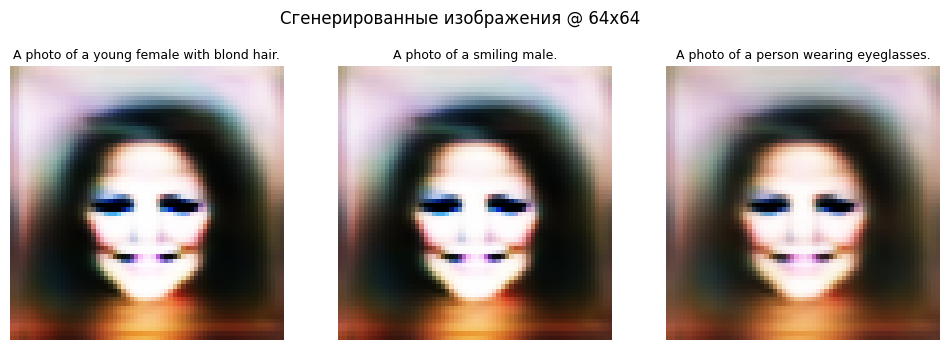

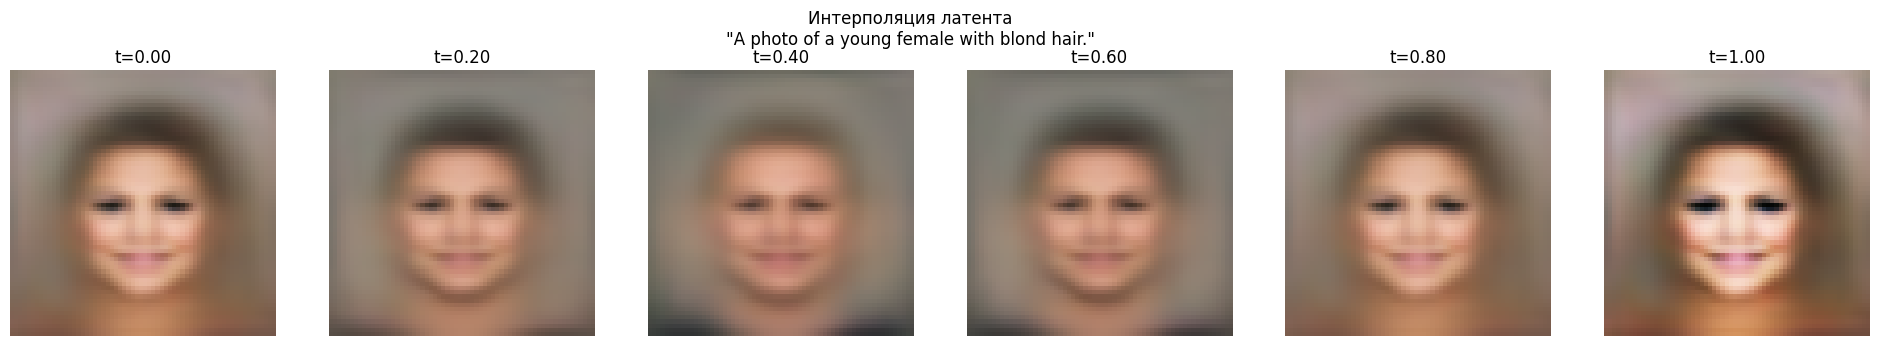

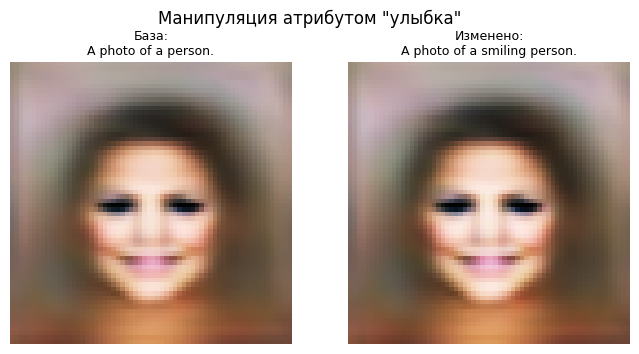

In [ ]:
# ---------- 13. Привязка кнопок ----------
def on_train_clicked(_):
    clear_output(wait=True)
    display(ui)
    train()

def on_metric_clicked(_):
    clear_output(wait=True)
    display(ui)
    run_metrics()

def on_generate_clicked(_):
    clear_output(wait=True)
    display(ui)
    run_generation()

def on_preview_clicked(_):
    clear_output(wait=True)
    display(ui)
    show_random_dataset_samples(k=8)

def on_delete_clicked(_):
    clear_output(wait=True)
    display(ui)
    delete_checkpoint()

def on_visual_clicked(_):
    clear_output(wait=True)
    display(ui)
    run_visual_analysis()

BTN_VISUALS.on_click(on_visual_clicked)
BTN_TRAIN.on_click(on_train_clicked)
BTN_METRIC.on_click(on_metric_clicked)
BTN_GEN.on_click(on_generate_clicked)
BTN_PREVIEW.on_click(on_preview_clicked)
BTN_DELETE.on_click(on_delete_clicked)

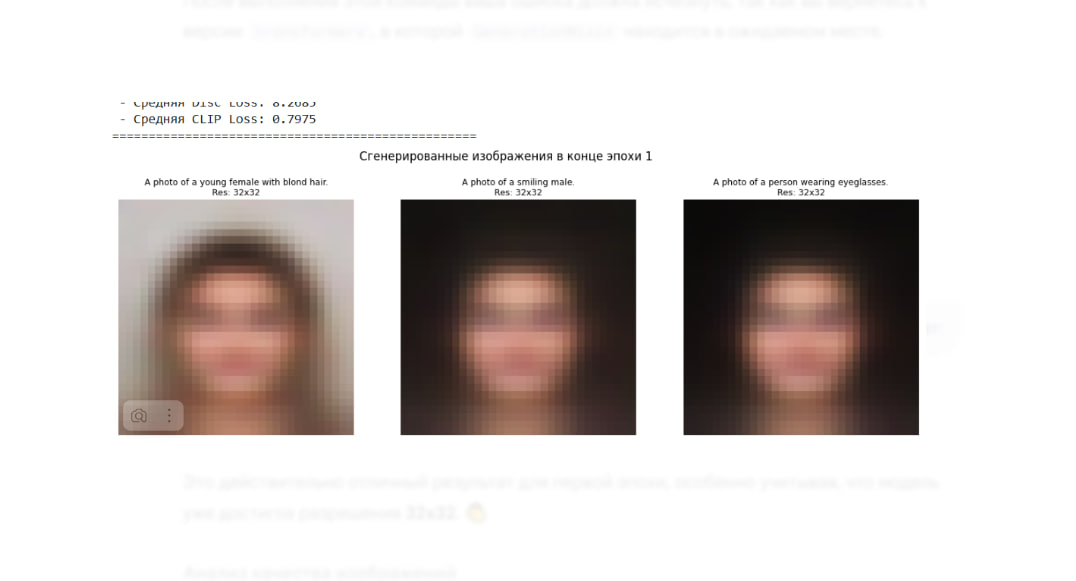
